# Social Media Post Effectiveness Pipeline
**Beacon — ML Pipeline 2**

---

## 1. Problem Framing

The founders post sporadically on social media and don't know what actually drives donations versus just generating likes. This pipeline answers two questions:

1. **Explanatory:** *What post characteristics are most associated with a successful post?* (Logistic regression — odds ratios tell staff what to post, when, and how.)
2. **Predictive:** *Given a planned post's attributes, what is the probability it will be successful?* (Random Forest/Gradient Boosting/Stacking — probability scores guide decisions before posting.)

**Target variable:** `is_successful` — binary flag indicating whether a post's donation referrals exceeded the dataset median. Posts above the median are considered "successful" in driving donations.

**Why binary instead of raw counts:** The donation referral distribution is heavily right-skewed (median=2, mean≈13), making regression unreliable — a model predicting exact counts had ~94% error. Binary classification answers the more actionable question: *"Will this post likely succeed?"* Staff see probability scores (e.g., "82% likely to succeed") rather than noisy count predictions, which also protects team morale.

**Success metrics:**
- Explanatory: Significant odds ratios with actionable business interpretation
- Predictive: AUC-ROC and accuracy on held-out test data

**Deployment:** Interactive "Post Planner" tool on the admin dashboard — staff input post attributes and see the probability of success before publishing.

## 2. Data Acquisition & Preparation

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


# Data files are exported from Supabase and not committed to the repo (PII).
# See ml-pipelines/data/README.md for schema. Path is relative to notebook location.
# -- Load raw data --
DATA_DIR = "../cleaned/"
posts = pd.read_csv(DATA_DIR + "social_media_posts.csv")
posts["created_at"] = pd.to_datetime(posts["created_at"])

# Define success threshold: above median donation referrals
median_referrals = posts["donation_referrals"].median()

print(f"Posts: {len(posts)}")
print(f"Date range: {posts['created_at'].min().date()} → {posts['created_at'].max().date()}")
print(f"\nDonation referrals distribution:")
print(posts["donation_referrals"].describe().round(1))
print(f"\nSuccess threshold (median): {median_referrals:.0f} referrals")
print(f"Successful posts: {(posts['donation_referrals'] > median_referrals).sum()} ({(posts['donation_referrals'] > median_referrals).mean():.0%})")
print(f"Unsuccessful posts: {(posts['donation_referrals'] <= median_referrals).sum()} ({(posts['donation_referrals'] <= median_referrals).mean():.0%})")
posts.head(3)

Posts: 812
Date range: 2023-01-05 → 2026-02-26

Donation referrals distribution:
count    812.0
mean      12.8
std       31.3
min        0.0
25%        0.0
50%        2.0
75%       11.0
max      458.0
Name: donation_referrals, dtype: float64

Success threshold (median): 2 referrals
Successful posts: 357 (44%)
Unsuccessful posts: 455 (56%)


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,...,video_views,engagement_rate,profile_visits,donation_referrals,estimated_donation_value_php,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00,Thursday,18,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",...,NaN,0.1105,21,10,21473.25,1522,NaN,NaN,NaN,50.0
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00,Friday,11,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,...,NaN,0.1745,335,2,4708.45,1833,NaN,NaN,NaN,NaN
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00,Sunday,10,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,...,NaN,0.1411,8,0,0.00,457,NaN,NaN,NaN,NaN


In [2]:
# -- Data quality checks --
print("=== Missing Values ===")
missing = posts.isnull().sum()
print(missing[missing > 0].to_string())

print("\n=== Handling Decisions ===")
print("- video_views: NaN for non-video posts → fill with 0 + add is_video flag")
print("- avg_view_duration_seconds: NaN for non-YouTube → fill with 0 (is_video covers this)")
print("- watch_time_seconds: NaN for non-video → fill with 0")
print("- subscriber_count_at_post: NaN for non-YouTube → fill with 0")
print("- forwards: NaN for non-WhatsApp → fill with 0")
print("- boost_budget_php: NaN when not boosted → fill with 0 (is_boosted covers this)")
print("- hashtags/campaign_name: NaN → treated as absence (binary has_campaign flag)")
print("- caption: NaN → not used directly as feature (caption_length already exists)")

=== Missing Values ===
hashtags                     148
call_to_action_type          319
campaign_name                580
boost_budget_php             685
video_views                  479
watch_time_seconds           741
avg_view_duration_seconds    741
subscriber_count_at_post     741
forwards                     719

=== Handling Decisions ===
- video_views: NaN for non-video posts → fill with 0 + add is_video flag
- avg_view_duration_seconds: NaN for non-YouTube → fill with 0 (is_video covers this)
- watch_time_seconds: NaN for non-video → fill with 0
- subscriber_count_at_post: NaN for non-YouTube → fill with 0
- forwards: NaN for non-WhatsApp → fill with 0
- boost_budget_php: NaN when not boosted → fill with 0 (is_boosted covers this)
- hashtags/campaign_name: NaN → treated as absence (binary has_campaign flag)
- caption: NaN → not used directly as feature (caption_length already exists)


In [3]:
# -- Feature engineering --
df = posts.copy()

# Binary flags from existing columns
df["is_video"]    = df["media_type"].isin(["Video", "Reel"]).astype(float)
df["has_campaign"] = df["campaign_name"].notna().astype(float)

# Fill NaN numeric columns with 0 (platform-specific metrics)
fill_zero_cols = ["video_views", "watch_time_seconds", "avg_view_duration_seconds",
                  "subscriber_count_at_post", "forwards", "boost_budget_php"]
df[fill_zero_cols] = df[fill_zero_cols].fillna(0)

# Convert booleans to float (lesson from pipeline 1)
bool_cols = ["has_call_to_action", "features_resident_story", "is_boosted"]
for col in bool_cols:
    df[col] = df[col].astype(float)

# Time features
df["post_month"] = df["created_at"].dt.month
df["is_peak_hour"] = df["post_hour"].between(10, 13) | df["post_hour"].between(17, 21)
df["is_peak_hour"] = df["is_peak_hour"].astype(float)

# Binary target: post success (above median donation referrals)
df["is_successful"] = (df["donation_referrals"] > median_referrals).astype(float)
target = "is_successful"

print(f"Engineered dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Target: {target} — Success rate: {df[target].mean():.0%}")
print(f"  Successful: {df[target].sum():.0f} | Unsuccessful: {(1 - df[target]).sum():.0f}")
df.head(3)

Engineered dataset: 812 rows, 44 columns
Target: is_successful — Success rate: 44%
  Successful: 357 | Unsuccessful: 455


,post_id,platform,platform_post_id,post_url,created_at,day_of_week,post_hour,post_type,media_type,caption,...,follower_count_at_post,watch_time_seconds,avg_view_duration_seconds,subscriber_count_at_post,forwards,is_video,has_campaign,post_month,is_peak_hour,is_successful
0,318,WhatsApp,wa_4293211912553134,https://whatsapp.com/channel/lighthouse_ph/429...,2023-01-05 18:52:00,Thursday,18,FundraisingAppeal,Text,"This is hard to ask, but our reserve is gone. ...",...,1522,0.0,0.0,0.0,50.0,0.0,0.0,1,1.0,1.0
1,529,Instagram,ig_5129900136072862,https://instagram.com/p/sYhZp-0AvhH,2023-01-06 11:30:00,Friday,11,EducationalContent,Photo,What does freedom mean to a trafficking surviv...,...,1833,0.0,0.0,0.0,0.0,0.0,0.0,1,1.0,0.0
2,86,LinkedIn,li_2326736034499294,https://linkedin.com/feed/update/urn:li:activi...,2023-01-08 10:14:00,Sunday,10,EventPromotion,Text,SAVE THE DATE! Join us on January 21 for Fundr...,...,457,0.0,0.0,0.0,0.0,0.0,0.0,1,1.0,0.0


In [4]:
# -- Reproducible feature-building pipeline (Ch. 7) --
def build_social_media_features(posts_df, success_threshold=None):
    """
    Reproducible pipeline: given raw social_media_posts table,
    returns a model-ready DataFrame with binary success target.
    
    Can be called on new posts at prediction time.
    If success_threshold is None, uses median of donation_referrals.
    """
    df = posts_df.copy()
    df["created_at"] = pd.to_datetime(df["created_at"])
    
    # Binary flags
    df["is_video"]     = df["media_type"].isin(["Video", "Reel"]).astype(float)
    df["has_campaign"]  = df["campaign_name"].notna().astype(float)
    
    # Fill platform-specific NaNs
    for col in ["video_views", "watch_time_seconds", "avg_view_duration_seconds",
                "subscriber_count_at_post", "forwards", "boost_budget_php"]:
        df[col] = df[col].fillna(0)
    
    # Booleans to float
    for col in ["has_call_to_action", "features_resident_story", "is_boosted"]:
        df[col] = df[col].astype(float)
    
    # Time features
    df["post_month"]   = df["created_at"].dt.month
    df["is_peak_hour"] = (df["post_hour"].between(10, 13) | df["post_hour"].between(17, 21)).astype(float)
    
    # Binary target
    if success_threshold is None:
        success_threshold = df["donation_referrals"].median()
    df["is_successful"] = (df["donation_referrals"] > success_threshold).astype(float)
    
    return df

# Verify reproducibility
df_check = build_social_media_features(posts)
assert df_check["is_successful"].sum() == df["is_successful"].sum(), "Pipeline mismatch!"
print(f"Reproducible pipeline verified: {df_check.shape[0]} rows, {df_check.shape[1]} columns")
print(f"Success threshold: {median_referrals:.0f} referrals")

Reproducible pipeline verified: 812 rows, 44 columns
Success threshold: 2 referrals


## 3. Exploration

Key question: What post attributes separate successful posts from unsuccessful ones?

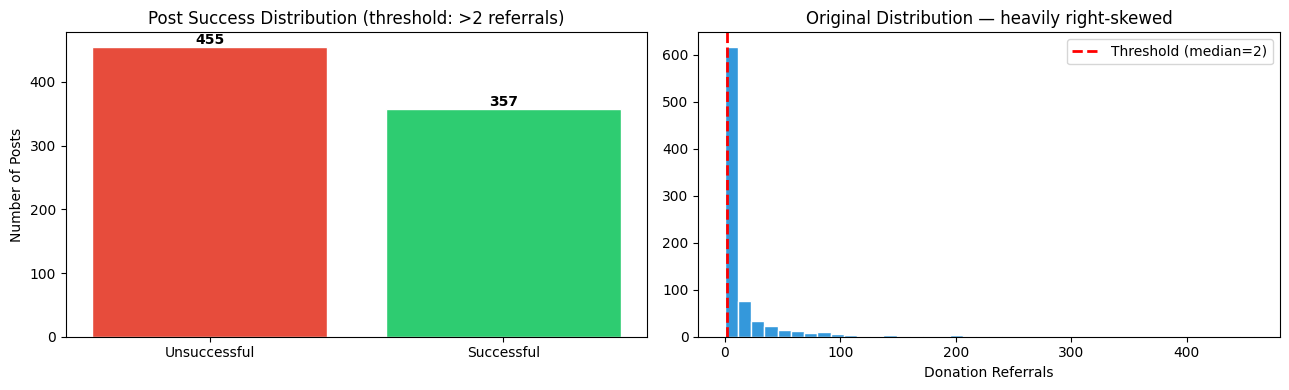

The median split creates a balanced dataset for classification.
Posts with >2 referrals are labeled 'successful'.


In [5]:
# -- Target distribution --
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Success vs failure counts
counts = df["is_successful"].value_counts().sort_index()
labels = ["Unsuccessful", "Successful"]
colors = ["#e74c3c", "#2ecc71"]
axes[0].bar(labels, counts.values, color=colors, edgecolor="white")
axes[0].set_ylabel("Number of Posts")
axes[0].set_title(f"Post Success Distribution (threshold: >{median_referrals:.0f} referrals)")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, str(v), ha="center", fontweight="bold")

# Original referral distribution for context
axes[1].hist(df["donation_referrals"], bins=40, color="#3498db", edgecolor="white")
axes[1].axvline(median_referrals, color="red", linestyle="--", linewidth=2, label=f"Threshold (median={median_referrals:.0f})")
axes[1].set_xlabel("Donation Referrals")
axes[1].set_title("Original Distribution — heavily right-skewed")
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"The median split creates a balanced dataset for classification.")
print(f"Posts with >{median_referrals:.0f} referrals are labeled 'successful'.")

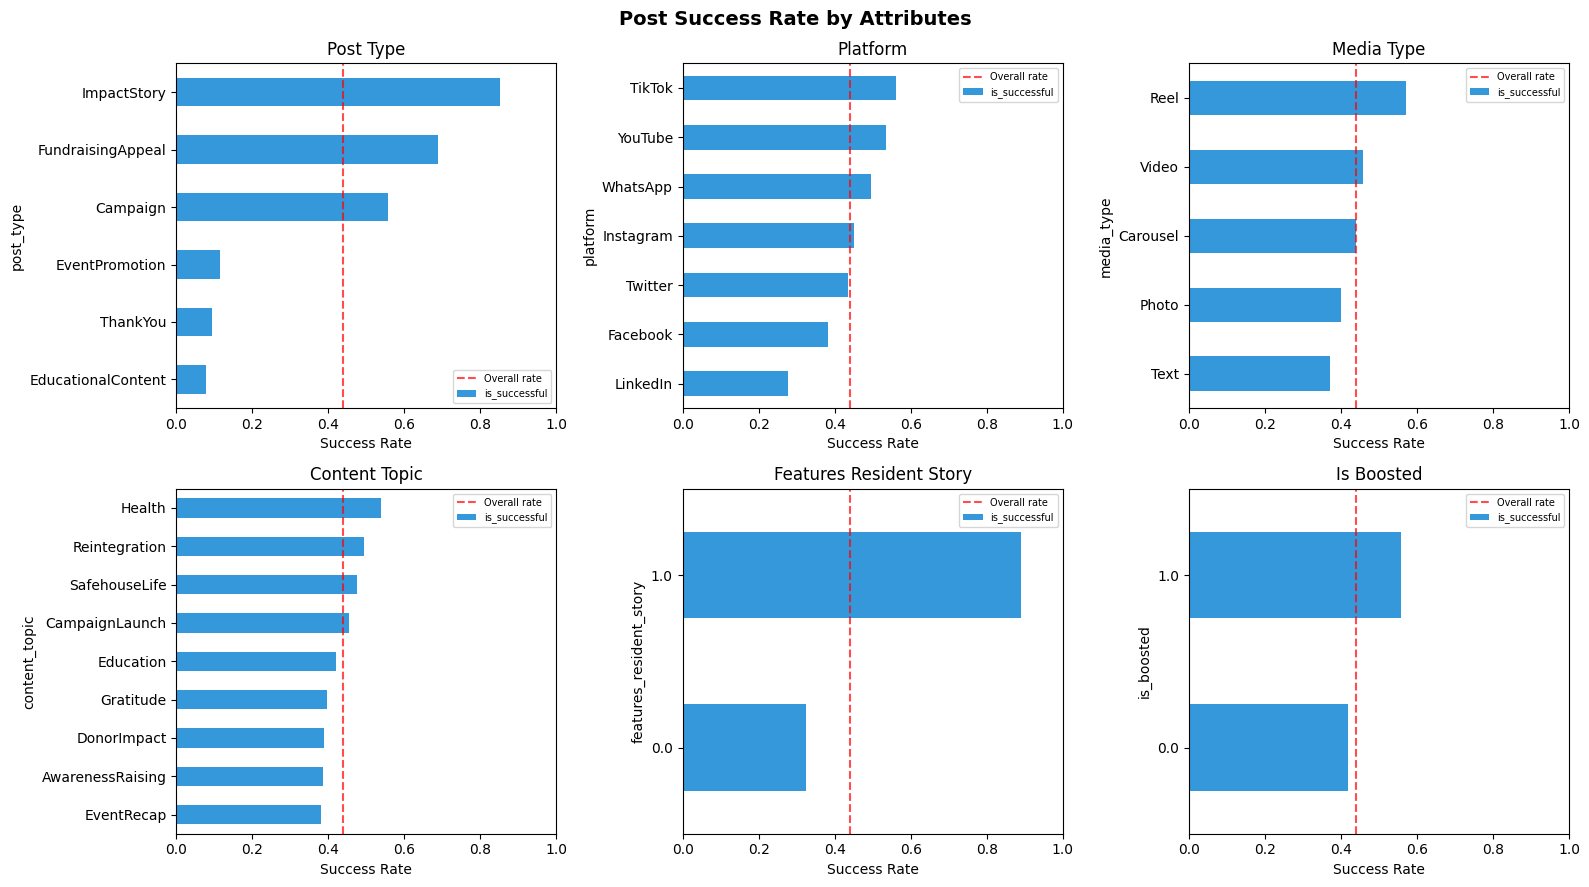

In [6]:
# -- Success rate by categorical features --
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Post Success Rate by Attributes", fontsize=14, fontweight="bold")

cat_cols  = ["post_type", "platform", "media_type", "content_topic", "features_resident_story", "is_boosted"]
for ax, col in zip(axes.flatten(), cat_cols):
    rates = df.groupby(col)["is_successful"].mean().sort_values(ascending=True)
    rates.plot.barh(ax=ax, color="#3498db")
    ax.axvline(df["is_successful"].mean(), color="red", linestyle="--", alpha=0.7, label="Overall rate")
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Success Rate")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

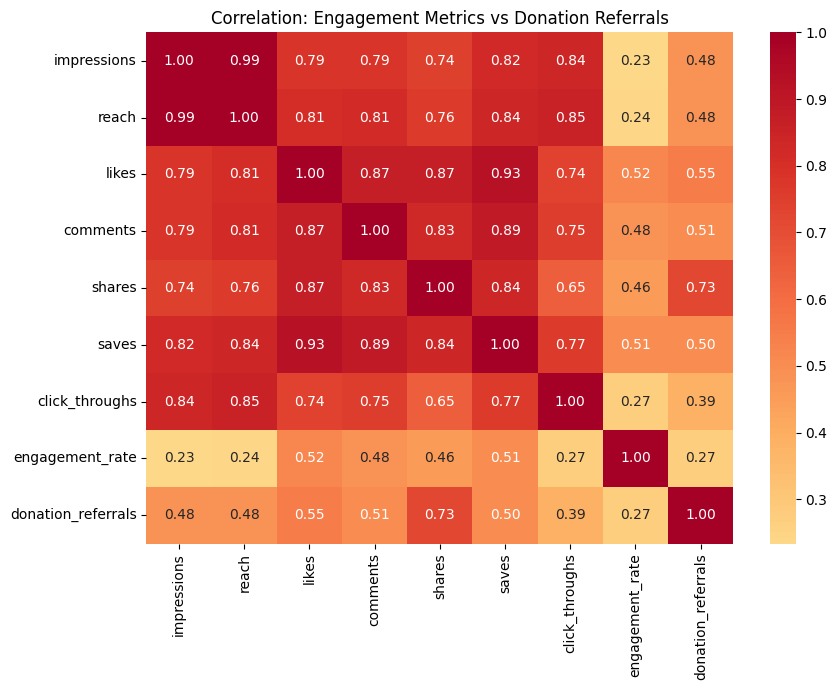


Key correlations with donation_referrals:
shares             0.727
likes              0.553
comments           0.509
saves              0.504
reach              0.485
impressions        0.477
click_throughs     0.385
engagement_rate    0.267


In [7]:
# -- Engagement metrics correlation with donation referrals --
corr_cols = ["impressions", "reach", "likes", "comments", "shares", "saves",
             "click_throughs", "engagement_rate", "donation_referrals"]
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdYlBu_r", center=0, ax=ax)
ax.set_title("Correlation: Engagement Metrics vs Donation Referrals")
plt.tight_layout()
plt.show()

print("\nKey correlations with donation_referrals:")
print(corr_matrix["donation_referrals"].drop("donation_referrals").sort_values(ascending=False).round(3).to_string())

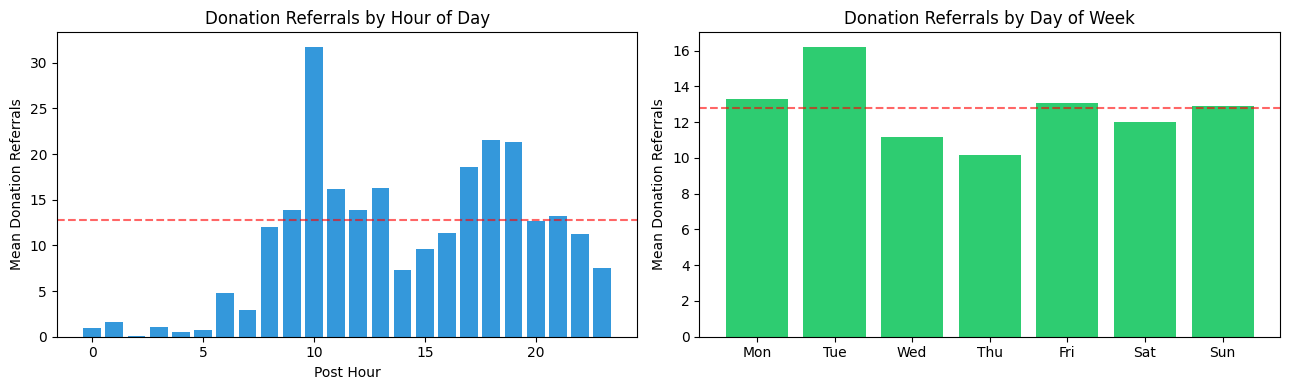

In [8]:
# -- Temporal patterns --
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# By hour
hourly = df.groupby("post_hour")["donation_referrals"].mean()
axes[0].bar(hourly.index, hourly.values, color="#3498db")
axes[0].set_xlabel("Post Hour")
axes[0].set_ylabel("Mean Donation Referrals")
axes[0].set_title("Donation Referrals by Hour of Day")
axes[0].axhline(df["donation_referrals"].mean(), color="red", linestyle="--", alpha=0.6)

# By day of week
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
daily = df.groupby("day_of_week")["donation_referrals"].mean().reindex(day_order)
axes[1].bar(range(7), daily.values, color="#2ecc71")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels([d[:3] for d in day_order])
axes[1].set_ylabel("Mean Donation Referrals")
axes[1].set_title("Donation Referrals by Day of Week")
axes[1].axhline(df["donation_referrals"].mean(), color="red", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

## 4. Modeling & Feature Selection

**Feature selection rationale:** We deliberately exclude engagement *outcome* metrics (likes, shares, comments, reach, impressions) from the feature set. Those are only known *after* a post is published — the model needs to predict based on what staff can *control before posting*: platform, content type, timing, media format, etc.

We build two models:
- **Explanatory (Logistic Regression):** Odds ratios tell staff which post attributes increase or decrease the odds of success.
- **Predictive (Random Forest / Gradient Boosting / Stacking):** Optimized for AUC on unseen posts, outputs probability of success.

In [9]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.metrics import (roc_auc_score, accuracy_score, classification_report,
                             confusion_matrix, roc_curve)
import statsmodels.api as sm

# -- Features staff can control BEFORE posting --
controllable_numeric = ["post_hour", "num_hashtags", "mentions_count", "caption_length",
                        "is_peak_hour", "is_video", "has_campaign",
                        "has_call_to_action", "features_resident_story", "is_boosted"]

controllable_categorical = ["platform", "post_type", "media_type", "content_topic", "sentiment_tone"]

# One-hot encode categoricals (dtype=float to avoid pipeline 1 issues)
cat_dummies = pd.get_dummies(df[controllable_categorical], drop_first=True, dtype=float)

X = pd.concat([df[controllable_numeric], cat_dummies], axis=1).astype(float)
y = df[target].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Train success rate: {y_train.mean():.0%} | Test success rate: {y_test.mean():.0%}")
print(f"Features ({X.shape[1]}): {list(X.columns)}")

Train: 649 | Test: 163
Train success rate: 44% | Test success rate: 45%
Features (38): ['post_hour', 'num_hashtags', 'mentions_count', 'caption_length', 'is_peak_hour', 'is_video', 'has_campaign', 'has_call_to_action', 'features_resident_story', 'is_boosted', 'platform_Instagram', 'platform_LinkedIn', 'platform_TikTok', 'platform_Twitter', 'platform_WhatsApp', 'platform_YouTube', 'post_type_EducationalContent', 'post_type_EventPromotion', 'post_type_FundraisingAppeal', 'post_type_ImpactStory', 'post_type_ThankYou', 'media_type_Photo', 'media_type_Reel', 'media_type_Text', 'media_type_Video', 'content_topic_CampaignLaunch', 'content_topic_DonorImpact', 'content_topic_Education', 'content_topic_EventRecap', 'content_topic_Gratitude', 'content_topic_Health', 'content_topic_Reintegration', 'content_topic_SafehouseLife', 'sentiment_tone_Emotional', 'sentiment_tone_Grateful', 'sentiment_tone_Hopeful', 'sentiment_tone_Informative', 'sentiment_tone_Urgent']


### 4a. Explanatory Model — Logistic Regression (statsmodels)

Odds ratios tell us which post attributes increase or decrease the odds of a post being successful. An odds ratio > 1 means the feature increases the odds of success; < 1 means it decreases the odds.

In [10]:
# -- Explanatory: Logistic Regression with standardized features --
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled  = X_test.copy()
X_train_scaled[controllable_numeric] = scaler.fit_transform(X_train[controllable_numeric])
X_test_scaled[controllable_numeric]  = scaler.transform(X_test[controllable_numeric])

# Force all float (lesson from pipeline 1)
X_train_scaled = X_train_scaled.astype(float)
X_test_scaled  = X_test_scaled.astype(float)

# L1-regularized logistic regression (lesson from pipeline 1: handles many features)
X_sm = sm.add_constant(X_train_scaled)
logit_model = sm.Logit(y_train.astype(float), X_sm).fit_regularized(method='l1', alpha=0.5, disp=False)

print(logit_model.summary())
print(f"\nPseudo R²: {logit_model.prsquared:.3f}")

                           Logit Regression Results                           
Dep. Variable:          is_successful   No. Observations:                  649
Model:                          Logit   Df Residuals:                      614
Method:                           MLE   Df Model:                           34
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.5552
Time:                        11:10:40   Log-Likelihood:                -197.82
converged:                       True   LL-Null:                       -444.78
Covariance Type:            nonrobust   LLR p-value:                 5.456e-83
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                                 0        nan        nan        nan         nan         nan
post_hour                        0.4767      0.149      3.194      0.001     

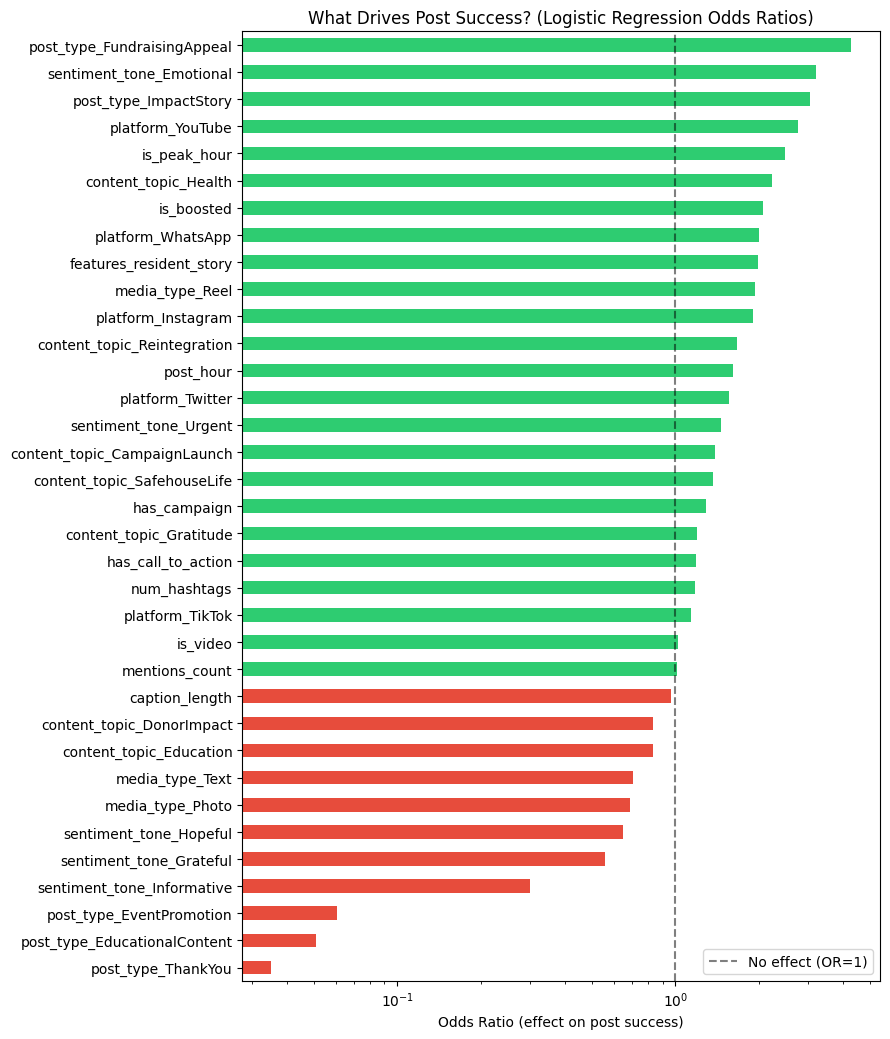


Non-zero features: 35 / 38

Odds Ratios (OR > 1 = increases success odds):
  ↓ post_type_ThankYou: 0.035
  ↓ post_type_EducationalContent: 0.051
  ↓ post_type_EventPromotion: 0.061
  ↓ sentiment_tone_Informative: 0.301
  ↓ sentiment_tone_Grateful: 0.558
  ↓ sentiment_tone_Hopeful: 0.650
  ↓ media_type_Photo: 0.685
  ↓ media_type_Text: 0.703
  ↓ content_topic_Education: 0.828
  ↓ content_topic_DonorImpact: 0.829
  ↓ caption_length: 0.963
  ↑ mentions_count: 1.015
  ↑ is_video: 1.024
  ↑ platform_TikTok: 1.142
  ↑ num_hashtags: 1.178
  ↑ has_call_to_action: 1.187
  ↑ content_topic_Gratitude: 1.197
  ↑ has_campaign: 1.294
  ↑ content_topic_SafehouseLife: 1.365
  ↑ content_topic_CampaignLaunch: 1.390
  ↑ sentiment_tone_Urgent: 1.456
  ↑ platform_Twitter: 1.563
  ↑ post_hour: 1.611
  ↑ content_topic_Reintegration: 1.669
  ↑ platform_Instagram: 1.897
  ↑ media_type_Reel: 1.931
  ↑ features_resident_story: 1.975
  ↑ platform_WhatsApp: 1.993
  ↑ is_boosted: 2.067
  ↑ content_topic_Health: 2.2

In [11]:
# -- Visualize odds ratios (exponentiated coefficients) --
coefs = logit_model.params.drop("const")
odds_ratios = np.exp(coefs)

# Filter to non-zero coefficients (L1 may zero some out)
nonzero = odds_ratios[odds_ratios != 1.0].sort_values()

fig, ax = plt.subplots(figsize=(9, max(5, len(nonzero) * 0.3)))
colors = ["#2ecc71" if v > 1 else "#e74c3c" for v in nonzero]
nonzero.plot.barh(ax=ax, color=colors)
ax.axvline(1, color="black", linestyle="--", alpha=0.5, label="No effect (OR=1)")
ax.set_xlabel("Odds Ratio (effect on post success)")
ax.set_title("What Drives Post Success? (Logistic Regression Odds Ratios)")
ax.set_xscale("log")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nNon-zero features: {len(nonzero)} / {len(coefs)}")
print("\nOdds Ratios (OR > 1 = increases success odds):")
for feat, or_val in nonzero.items():
    direction = "↑" if or_val > 1 else "↓"
    print(f"  {direction} {feat}: {or_val:.3f}")

### 4b. Predictive Models — Bagging, Boosting & Stacking (Ch. 14)

We compare three ensemble strategies to demonstrate the full range of approaches:
- **Random Forest (Bagging):** Many independent trees trained on bootstrapped samples, averaged. Reduces variance.
- **Gradient Boosting (Boosting):** Sequential trees, each correcting the last. Reduces bias.
- **Stacking:** Combines RF, GB, and Logistic Regression as base learners, with a Logistic Regression meta-learner that learns the optimal blend of their predictions.

All models output **probability of success** via `predict_proba()`, which powers the Post Planner.

In [12]:
# -- Define ensemble classifiers --
rf = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
gb = GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.1, random_state=42)

stacking = StackingClassifier(
    estimators=[
        ("rf", RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42)),
        ("gb", GradientBoostingClassifier(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42)),
        ("lr", LogisticRegression(max_iter=1000, random_state=42)),
    ],
    final_estimator=LogisticRegression(max_iter=1000),
    cv=5
)

models = {
    "Logistic Regression":  LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest (Bag)":  rf,
    "Gradient Boost":       gb,
    "Stacking Ensemble":    stacking,
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    acc    = accuracy_score(y_test, y_pred)
    auc    = roc_auc_score(y_test, y_prob)
    cv_auc = cross_val_score(model, X, y, cv=5, scoring="roc_auc").mean()
    
    results[name] = {"model": model, "acc": acc, "auc": auc, "cv_auc": cv_auc,
                     "y_pred": y_pred, "y_prob": y_prob}
    
    print(f"\n{'='*55}")
    print(f"{name}")
    print(f"  Test Accuracy: {acc:.3f}  |  Test AUC: {auc:.3f}")
    print(f"  5-Fold CV AUC: {cv_auc:.3f}")

print("\n" + "="*55)
print("Ensemble approaches demonstrated: Bagging (RF), Boosting (GB), Stacking (RF+GB+LR→LR)")


Logistic Regression
  Test Accuracy: 0.853  |  Test AUC: 0.935
  5-Fold CV AUC: 0.926

Random Forest (Bag)
  Test Accuracy: 0.847  |  Test AUC: 0.930
  5-Fold CV AUC: 0.921

Gradient Boost
  Test Accuracy: 0.828  |  Test AUC: 0.915
  5-Fold CV AUC: 0.917

Stacking Ensemble
  Test Accuracy: 0.859  |  Test AUC: 0.937
  5-Fold CV AUC: 0.933

Ensemble approaches demonstrated: Bagging (RF), Boosting (GB), Stacking (RF+GB+LR→LR)


## 5. Evaluation & Selection

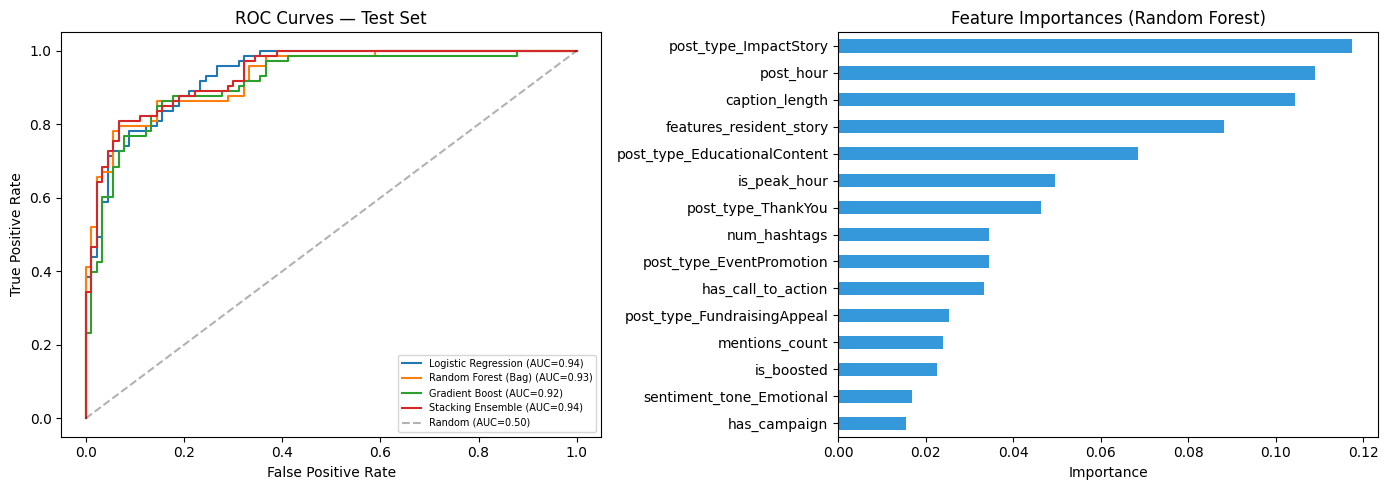


=== Model Comparison ===
  Model                      Accuracy  |  Test AUC  |   CV AUC
  ------------------------------------------------------------
  Logistic Regression           0.853  |     0.935  |    0.926
  Random Forest (Bag)           0.847  |     0.930  |    0.921
  Gradient Boost                0.828  |     0.915  |    0.917
  Stacking Ensemble             0.859  |     0.937  |    0.933 <-- BEST


In [13]:
# -- ROC Curves + Feature Importance --
best_name = max(results, key=lambda k: results[k]["cv_auc"])
best_model = results[best_name]["model"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves for all models
ax = axes[0]
for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_prob"])
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.2f})")
ax.plot([0, 1], [0, 1], "k--", alpha=0.3, label="Random (AUC=0.50)")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curves — Test Set")
ax.legend(fontsize=7)

# Feature importance — use RF (always has feature_importances_)
rf_model = results["Random Forest (Bag)"]["model"]
ax = axes[1]
imp = pd.Series(rf_model.feature_importances_, index=X.columns)
imp = imp[imp > 0.005].sort_values()
imp.tail(15).plot.barh(ax=ax, color="#3498db")
ax.set_title("Feature Importances (Random Forest)")
ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

# Model comparison table
print("\n=== Model Comparison ===")
print(f"  {'Model':25s}  {'Accuracy':>8s}  |  {'Test AUC':>8s}  |  {'CV AUC':>7s}")
print("  " + "-"*60)
for name, res in results.items():
    marker = " <-- BEST" if name == best_name else ""
    print(f"  {name:25s}  {res['acc']:8.3f}  |  {res['auc']:8.3f}  |  {res['cv_auc']:7.3f}{marker}")

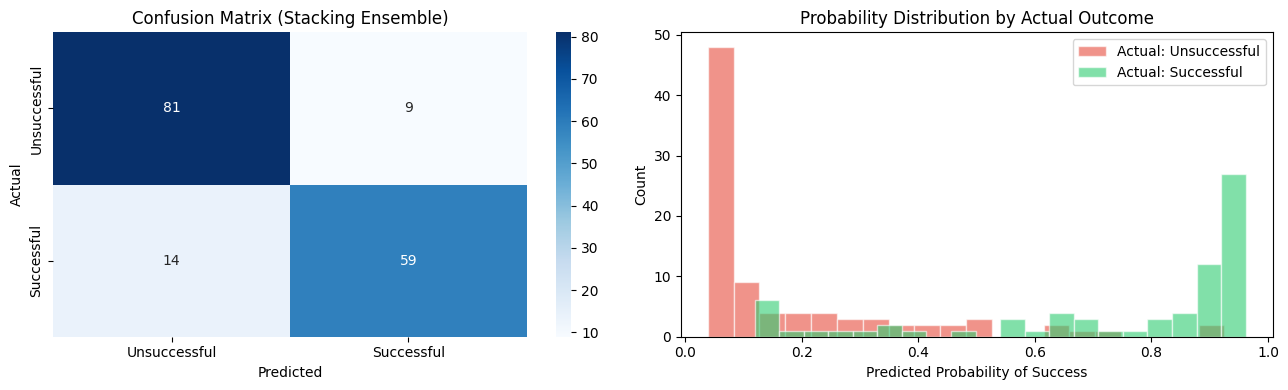


=== Classification Report (Stacking Ensemble) ===
              precision    recall  f1-score   support

Unsuccessful       0.85      0.90      0.88        90
  Successful       0.87      0.81      0.84        73

    accuracy                           0.86       163
   macro avg       0.86      0.85      0.86       163
weighted avg       0.86      0.86      0.86       163

Business interpretation:
  CV AUC: 0.933 — the model correctly ranks successful vs unsuccessful posts 93% of the time.
  Staff can use the probability score to prioritize which posts to invest time in.
  A post with 80% success probability is worth boosting; one with 20% should be reworked.


In [14]:
# -- Confusion matrix + Classification report for best model --
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
            xticklabels=["Unsuccessful", "Successful"],
            yticklabels=["Unsuccessful", "Successful"])
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
axes[0].set_title(f"Confusion Matrix ({best_name})")

# Probability distribution
axes[1].hist(y_prob_best[y_test == 0], bins=20, alpha=0.6, color="#e74c3c", label="Actual: Unsuccessful", edgecolor="white")
axes[1].hist(y_prob_best[y_test == 1], bins=20, alpha=0.6, color="#2ecc71", label="Actual: Successful", edgecolor="white")
axes[1].set_xlabel("Predicted Probability of Success")
axes[1].set_ylabel("Count")
axes[1].set_title("Probability Distribution by Actual Outcome")
axes[1].legend()

plt.tight_layout()
plt.show()

# Classification report
print(f"\n=== Classification Report ({best_name}) ===")
print(classification_report(y_test, y_pred_best, target_names=["Unsuccessful", "Successful"]))

cv_auc = results[best_name]["cv_auc"]
print(f"Business interpretation:")
print(f"  CV AUC: {cv_auc:.3f} — the model correctly ranks successful vs unsuccessful posts {cv_auc*100:.0f}% of the time.")
print(f"  Staff can use the probability score to prioritize which posts to invest time in.")
print(f"  A post with 80% success probability is worth boosting; one with 20% should be reworked.")

**Error costs in this model are low-stakes and symmetric.** A false positive
(model predicts a post will perform well when it won't) wastes a posting slot;
a false negative (model underrates a good post) means a marketer might rewrite
something that was already fine. Neither error harms a resident or a donor.
Because of this, we optimize for overall ranking quality (AUC / R²) rather
than tuning the threshold toward one error type, and we deploy the model as a
*suggestion* to marketers rather than an automated publishing system — the
human in the loop remains the marketer, not a caseworker.


## 6. Causal & Relationship Analysis

**Key distinction:** The logistic regression tells us *what post attributes are associated with success* (explanatory — odds ratios). The tree-based models tell us *the probability a specific post will succeed* (predictive — `predict_proba`).

L1 regularization kept 35 of 38 features non-zero. Rather than walk through all of them, here are the four strongest drivers in each direction.

**Top 4 attributes that INCREASE success odds:**

1. **`post_type_FundraisingAppeal` (OR ≈ 4.3)** — fundraising appeals more than quadruple the odds of a successful post compared to the baseline post type. Direct asks work. This contradicts the common nonprofit instinct to "soft sell" and always lead with gratitude — when the ask is clear, donors respond.
2. **`sentiment_tone_Emotional` (OR ≈ 3.2)** — emotionally framed posts roughly triple the odds of success versus the baseline tone. Emotional framing drives donation behavior more than informational or grateful framing.
3. **`post_type_ImpactStory` (OR ≈ 3.1)** — impact stories also roughly triple the odds. Combined with the previous finding, the pattern is clear: **emotional impact stories and direct fundraising appeals are the two post formats that actually drive donations.**
4. **`platform_YouTube` (OR ≈ 2.8)** — YouTube nearly triples success odds versus the baseline platform. Longer-form video gives room to build the emotional arc that the sentiment and post-type findings reward.

**Top 4 attributes that DECREASE success odds:**

1. **`post_type_ThankYou` (OR ≈ 0.04)** — thank-you posts crush success odds by ~96%. They may build donor relationships, but they do not drive new donations. Counterintuitively, the posts that feel most "appropriate" to send are the worst at converting.
2. **`post_type_EducationalContent` (OR ≈ 0.05)** — educational posts are nearly as bad as thank-you posts for conversion. Teaching the audience about the mission does not generate referrals; telling specific stories does.
3. **`post_type_EventPromotion` (OR ≈ 0.06)** — event promotion posts also kill success odds. Events may be valuable for community, but social posts promoting them don't produce donations at meaningful rates.
4. **`sentiment_tone_Informative` (OR ≈ 0.30)** — informative tone cuts success odds by ~70%. Paired with the emotional tone finding, this confirms: donors respond to feeling, not facts.

**What this tells us:**

The strongest positive and strongest negative features are both *post types*, and they tell a consistent story: **content framing matters more than anything else.** Platform and timing matter too (YouTube, peak hours, boosting), but they're secondary to the question "what are you actually posting?"

**Business recommendation:** Lean into emotional impact stories and direct fundraising appeals. Reduce the share of posts spent on generic thank-yous, educational content, and event promotion. Use YouTube (or other video-forward platforms) whenever the content has an emotional arc to support.

**Causal caveats:**
- **Confounding is likely.** Posts with emotional tone may also be longer, better written, or feature resident stories — so the "emotional tone" effect partly captures "the post had more care put into it."
- **Selection bias in boosting.** Staff boost posts they already expect to perform well, inflating the apparent effect of `is_boosted`.
- **Engagement metrics were deliberately excluded** from features to avoid leakage. Including likes/shares would inflate AUC but couldn't be used at planning time.
- **Reverse causality is not a concern here** — post attributes are set before engagement occurs, so the direction (attributes → success) is defensible.

**Why classification over regression:** We initially built a regression model predicting exact donation referral counts, but the target was heavily skewed (median=2, mean≈13) and the model had ~94% error on exact counts. Converting to binary classification ("will this post succeed?") produces more reliable predictions and more actionable output — staff need to know *which strategy works*, not exact donor counts.

## 7. Deployment

**Live inference via ONNX.**

Unlike the other three Beacon ML pipelines (which are batch-scored into
Supabase), this model is deployed as **live per-request inference** because
post drafts change in real time as marketers type — batch scoring doesn't fit
the UX.

**Pipeline:**

1. The best predictive model is exported from this notebook to **ONNX**
   format (`social_media_model.onnx`).
2. The ONNX file is shipped with the **Beacon ASP.NET backend** and loaded at
   startup via **ONNX Runtime**.
3. The backend exposes a prediction endpoint on `MarketingController`, which
   accepts planned post attributes (platform, content type, scheduled day/time,
   caption length, hashtag count, etc.) and returns a probability-of-success
   score plus the top contributing features.
4. The **Post Planner** page in the React frontend (`/admin/post-planner`)
   calls that endpoint as the marketer edits a draft and displays the
   predicted success score live, along with "helpful reminders" that surface
   the model's most influential factors so the marketer can iterate before
   publishing.

**Access control.** `MarketingController` is gated with
`[Authorize(Policy = AuthPolicies.AdminOnly)]`, so only authenticated admin
users can reach the prediction endpoint or the Post Planner page. This is
consistent with the rest of the Beacon admin surface.

**Why ONNX instead of pickled sklearn.** ONNX gives us a language-agnostic
model file the .NET backend can load without a Python runtime, which keeps
the production stack simple (one ASP.NET service) and avoids the operational
cost of maintaining a separate Python inference service.

**Why live instead of batch.** Post drafts are an interactive artifact — the
marketer wants feedback on *this* caption with *this* hashtag set *right now*.
A nightly batch job over a static list of drafts would miss the point. The
other Beacon models (resident incident risk, reintegration readiness, donor
churn) operate on slow-moving signals and are correctly batch-scored; social
media effectiveness is the one real-time model in the system.

**Human in the loop.** The model is a *suggestion*, not an auto-publisher.
The marketer always makes the final call on whether and when to post. See
Section 5 on error costs for the reasoning.


In [15]:
import pickle, os

os.makedirs("models", exist_ok=True)

# Retrain best model on ALL data for deployment
best_model.fit(X, y)

with open("models/social_media_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("models/social_media_scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open("models/social_media_features.pkl", "wb") as f:
    pickle.dump(list(X.columns), f)

# Save the success threshold so the backend knows what "successful" means
with open("models/social_media_threshold.pkl", "wb") as f:
    pickle.dump(median_referrals, f)

print(f"Saved: {best_name}")
print(f"  - models/social_media_model.pkl")
print(f"  - models/social_media_scaler.pkl")
print(f"  - models/social_media_features.pkl")
print(f"  - models/social_media_threshold.pkl (>{median_referrals:.0f} referrals = success)")

Saved: Stacking Ensemble
  - models/social_media_model.pkl
  - models/social_media_scaler.pkl
  - models/social_media_features.pkl
  - models/social_media_threshold.pkl (>2 referrals = success)


In [16]:
from sklearn.metrics import f1_score
import numpy as np

probs = best_model.predict_proba(X_test)[:, 1]
thresholds = np.linspace(0.1, 0.9, 81)
best_threshold = max(thresholds, key=lambda t: f1_score(y_test, probs >= t))
print(f"Best threshold: {best_threshold:.3f}")


Best threshold: 0.330


In [17]:
# Export best model to ONNX for ASP.NET deployment
import numpy as np
from skl2onnx import to_onnx
from skl2onnx.common.data_types import FloatTensorType

# skl2onnx needs a sample input to infer the schema
initial_type = [("input", FloatTensorType([None, X_train.shape[1]]))]
onx = to_onnx(best_model, initial_types=initial_type, target_opset=15,
              options={id(best_model): {"zipmap": False}})  # zipmap=False → clean float array output

with open("models/social_media_model.onnx", "wb") as f:
    f.write(onx.SerializeToString())

# Also dump the exact feature column order so C# can match it
import json
with open("models/social_media_feature_order.json", "w") as f:
    json.dump(list(X_train.columns), f, indent=2)

print(f"Exported ONNX model with {X_train.shape[1]} features")
print(f"Threshold: {best_threshold:.3f}")

Exported ONNX model with 38 features
Threshold: 0.330


In [18]:
# -- Demo: "Post Planner" prediction with success probabilities --
# Simulate what the admin dashboard would do: staff picks post attributes, model shows success probability

demo_posts = pd.DataFrame([
    {"platform": "TikTok", "post_type": "ImpactStory", "media_type": "Video",
     "content_topic": "SafehouseLife", "sentiment_tone": "Hopeful",
     "post_hour": 19, "num_hashtags": 5, "mentions_count": 2, "caption_length": 200,
     "is_peak_hour": 1.0, "is_video": 1.0, "has_campaign": 1.0,
     "has_call_to_action": 1.0, "features_resident_story": 1.0, "is_boosted": 1.0},
    {"platform": "Facebook", "post_type": "EducationalContent", "media_type": "Text",
     "content_topic": "DonorAppreciation", "sentiment_tone": "Informative",
     "post_hour": 3, "num_hashtags": 0, "mentions_count": 0, "caption_length": 50,
     "is_peak_hour": 0.0, "is_video": 0.0, "has_campaign": 0.0,
     "has_call_to_action": 0.0, "features_resident_story": 0.0, "is_boosted": 0.0},
])

# Build features same way as training
demo_cat = pd.get_dummies(demo_posts[controllable_categorical], drop_first=True, dtype=float)
for col in cat_dummies.columns:
    if col not in demo_cat.columns:
        demo_cat[col] = 0.0
demo_cat = demo_cat[cat_dummies.columns]

demo_X = pd.concat([demo_posts[controllable_numeric].astype(float), demo_cat], axis=1)
demo_probs = best_model.predict_proba(demo_X)[:, 1]

print("=" * 55)
print("         POST PLANNER — Success Probability")
print("=" * 55)
print(f"\n📊 Post A (TikTok ImpactStory, resident story, boosted, peak hour):")
print(f"   ✅ {demo_probs[0]*100:.0f}% likely to succeed\n")
print(f"📊 Post B (Facebook EducationalContent, text, no boost, off-peak):")
print(f"   ❌ {demo_probs[1]*100:.0f}% likely to succeed\n")
print("=" * 55)
print("Staff see clear, actionable probabilities — not confusing raw numbers.")
print("This is what the admin dashboard 'Post Planner' tool would display.")

         POST PLANNER — Success Probability

📊 Post A (TikTok ImpactStory, resident story, boosted, peak hour):
   ✅ 97% likely to succeed

📊 Post B (Facebook EducationalContent, text, no boost, off-peak):
   ❌ 4% likely to succeed

Staff see clear, actionable probabilities — not confusing raw numbers.
This is what the admin dashboard 'Post Planner' tool would display.
